## O Problema - Alocação de tarefas (Parallel Machine Scheduling)
Suponha que tenhamos **m tarefas** e **n maquinas** identicas. Onde as tarefas demandam uma quantidade de tmepo diferentes. O objetivo é distribuir as tarefas entre as máquinas de forma a reduzir o numero de maquinas em ociosidade, reduzindo também o tempo total para finalizar todas as tarefas.

#### DADOS DO PROBLEMA:

Número de tarefas: 30
Número de máquinas: 5
Tipo de máquinas: Idênticas
Objetivo: Minimizar o makespan (tempo total de execução)


#### FUNÇÃO OBJETIVO:

Minimizar C_max

Onde:
- C_max é o tempo da máquina que terminar por último
- Cada tarefa deve ser alocada a exatamente uma máquina
- Todas as máquinas podem executar qualquer tarefa

#### RESTRIÇÕES:

1. Cada tarefa deve ser atribuída a uma e somente uma máquina.
2. Cada máquina pode processar uma tarefa por vez.
3. O tempo de execução de uma tarefa é fixo e conhecido.
4. As máquinas são idênticas em desempenho (tempo de execução é o mesmo em qualquer uma).
5. Não há preempção (tarefa, uma vez iniciada, deve ser concluída sem interrupção).
6. Não há dependência entre tarefas (todas são independentes).

#### Tabela de Tarefas

Dentro do arquivo "Aula11_-_Problema_maquinas_paralelas_facil.txt" temos uma tabela que segue o seguinte formato:

ID_Tarefa   Tempo_Processamento
1           12
2           5
3           9
...
30          2

## INSTRUÇÕES:

- Implementar a metaheurística Simulated Annealing
- Ler os dados de entrada e produzir uma solução que atribua cada tarefa a uma das 5 máquinas.
- Avaliar o makespan (C_max) da solução e otimizá-lo.
- Ao final, reportar:
    a) Atribuição final de tarefas às máquinas
    b) Valor final do makespan
    c) Tempo de execução do algoritmo
    d) Gráfico ou análise da evolução da solução, se possível

## Simulated Annealing

Simulated Annealing (SA) é uma metaheurística inspirada no processo físico de recozimento (annealing), no qual um material é aquecido e depois resfriado lentamente para reduzir defeitos e alcançar um estado resfriado. Em otimização combinatória, usamos essa analogia para escapar de mínimos locais e buscar soluções de melhor qualidade.

### Ideia Central
Mantemos uma solução e a cada iteração, geramos uma solução vizinha (perturbação pequena). Se a solução vizinha é melhor (menor makespan), ela é aceita. Se é pior, ainda pode ser aceita com uma probabilidade que diminui conforme:
- O delta aumenta (diferença em relação a ultima solução)
- A temperatura diminui (ela é reduzida a cada iteração)

Isso permite explorar o espaço de busca no início (aceitando piores soluções) e refinar no final aceitando majoritariamente soluções melhores.

### Componentes no código
1. Representação da solução: um dicionário `assignment` que associa cada tarefa a uma máquina (índice 0..N-1).
2. Função objetivo: `calculate_makespan` calcula o makespan (tempo máximo das máquinas), que queremos minimizar.
3. Solução inicial: `initial_solution` faz uma atribuição aleatória das tarefas às máquinas.
4. Vizinho: `generate_neighbor` altera a máquina de duas tarefas escolhidas aleatoriamente.
5. Critério de aceitação: Se `delta = custo_vizinho - custo_atual`:
   - Se `delta < 0`: aceita (melhora).
   - Caso contrário: aceita com probabilidade $e^{-delta / T}$.
6. Resfriamento: `temperature *= cooling_rate` a cada iteração.
7. Parada: número máximo de iterações ou temperatura abaixo de um determinado valor.

### Parâmetros principais
- `initial_temp`: quanto maior, mais explorações arriscadas no início.
- `cooling_rate` (0 < r < 1): valores próximos de 1 resfriam lentamente (mais exploração), menores resfriam rápido (mais risco de ficar preso em mínimos locais).
- `max_iterations`: limite de iterações.

### Vantagens
- Simples de implementar.
- Consegue escapar de mínimos locais no começo da busca.

### Desvantagens
- Sensível à escolha de parâmetros.
- Não garante ótimo global.

### Possíveis melhorias futuras
- Estratégia adaptativa de temperatura (ex: reheating).
- Vizinhança mais informada (mover tarefa da máquina mais carregada para a menos carregada).
- Critério de parada baseado em estagnação (ex: X iterações sem melhora).
- Execuções múltiplas com valores iniciais diferentes para testar melhor a robustez do método

### Resumo do fluxo
1. Gera solução inicial.
2. Calcula custo (makespan).
3. Loop:
   - Gera vizinho.
   - Calcula custo.
   - Decide aceitar ou não.
   - Atualiza melhor solução se aplicável.
   - Atualiza temperatura.
4. Retorna melhor solução e histórico de custos.

Com isso, obtemos uma abordagem flexível para balancear exploração e exploração controlada do espaço de alocação de tarefas em máquinas paralelas.

In [9]:
import random
import math
import time
import matplotlib.pyplot as plt

# Read the data
tasks = {}
with open('Aula11_-_Problema_maquinas_paralelas_facil.txt', 'r') as f:
    next(f)  # Skip header
    for line in f:
        parts = line.strip().split()
        task_id = int(parts[0])
        time_proc = int(parts[1])
        tasks[task_id] = time_proc

num_tasks = len(tasks)
num_machines = 5
print(f"Number of tasks: {num_tasks}")
print(f"Number of machines: {num_machines}")
# tasks dictionary is a dictionary where keys are task IDs and values are processing times.
print("Tasks:", tasks)

Number of tasks: 30
Number of machines: 5
Tasks: {1: 12, 2: 5, 3: 9, 4: 7, 5: 4, 6: 11, 7: 8, 8: 6, 9: 10, 10: 3, 11: 7, 12: 9, 13: 5, 14: 6, 15: 4, 16: 8, 17: 12, 18: 3, 19: 7, 20: 8, 21: 3, 22: 7, 23: 8, 24: 11, 25: 4, 26: 9, 27: 10, 28: 13, 29: 5, 30: 2}


In [ ]:
# calculate the total time taken by the machine that finishes last
# assignment is a dictionary where keys are task IDs and values are machine numbers (0 to num_machines-1)
def calculate_makespan(assignment, tasks, num_machines):
    machine_loads = [0] * num_machines
    for task, machine in assignment.items():
        machine_loads[machine] += tasks[task]
    return max(machine_loads)

# generate an initial random assignment of tasks to machines
def initial_solution(tasks, num_machines):
    assignment = {}
    for task in tasks:
        assignment[task] = random.randint(0, num_machines - 1)
    return assignment

# change the machine assignment of two random tasks
def generate_neighbor(assignment, num_machines):
    neighbor = assignment.copy()
    task1, task2 = random.sample(list(assignment.keys()), 2)
    neighbor[task1] = random.randint(0, num_machines - 1)
    neighbor[task2] = random.randint(0, num_machines - 1)
    return neighbor

Stopping early due to low temperature.
Number of iterations: 269
Best makespan: 46
Execution time: 0.00 seconds
Best assignment:
Machine 0: Tasks [11, 14, 15, 16, 18, 20, 27], Load: 46
Machine 1: Tasks [6, 10, 12, 13, 17, 29], Load: 45
Machine 2: Tasks [1, 4, 8, 22, 26], Load: 41
Machine 3: Tasks [2, 5, 9, 21, 24, 25, 30], Load: 39
Machine 4: Tasks [3, 7, 19, 23, 28], Load: 45


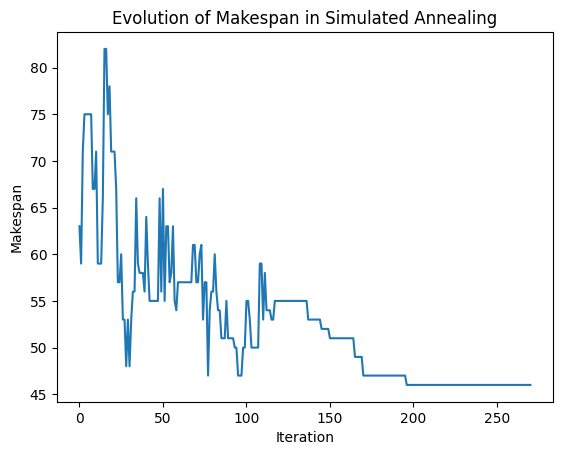

In [27]:
# simulated annealing algorithm
# recieves tasks dictionary, number of machines, initial temperature, cooling rate, and max iterations
def simulated_annealing(tasks, num_machines, initial_temp=1000, cooling_rate=0.95, max_iterations=10000):
    # generate initial solution
    current_solution = initial_solution(tasks, num_machines)
    # calculate initial cost
    current_cost = calculate_makespan(current_solution, tasks, num_machines)
    # keep track of the best solution and best cost found
    best_solution = current_solution.copy()
    best_cost = current_cost
    
    temperature = initial_temp
    # track cost evolution
    costs = [current_cost]
    
    for iteration in range(max_iterations):
        neighbor = generate_neighbor(current_solution, num_machines)
        neighbor_cost = calculate_makespan(neighbor, tasks, num_machines)
        
        delta = neighbor_cost - current_cost
        if delta < 0 or random.random() < math.exp(-delta / temperature):
            current_solution = neighbor
            current_cost = neighbor_cost
            if current_cost < best_cost:
                best_solution = current_solution.copy()
                best_cost = current_cost
        
        # keep track of cost evolution
        costs.append(current_cost)
        temperature *= cooling_rate
        
        # stopping criterion: if temperature is very low
        # 1e-3 = 0.001
        if temperature < 1e-3:
            print("Stopping early due to low temperature.")
            print("Number of iterations:", iteration)
            break
    
    return best_solution, best_cost, costs

# Run the algorithm
start_time = time.time()
best_assignment, best_makespan, cost_history = simulated_annealing(tasks, num_machines)
end_time = time.time()

print(f"Best makespan: {best_makespan}")
print(f"Execution time: {end_time - start_time:.2f} seconds")
print("Best assignment:")
for machine in range(num_machines):
    tasks_on_machine = [task for task, m in best_assignment.items() if m == machine]
    load = sum(tasks[t] for t in tasks_on_machine)
    print(f"Machine {machine}: Tasks {tasks_on_machine}, Load: {load}")

# Plot the evolution
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Makespan')
plt.title('Evolution of Makespan in Simulated Annealing')
plt.show()